In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import find_peaks

from evaluation_package import filetools as ft
from evaluation_package import esr
from evaluation_package import utils as ut
import evaluation_package.__version__ as version

In [2]:
# Specify the experiment type
experiment_type = "ESR"

# Specify the subfolder list as a standard string path, eg /folder1/folder2
subfolder = ""

# Load the datafiles natively
yaml_config, data = ft.load_experiment_data(experiment_type, subfolders=subfolder, print=True, date_key="2026-01-20-14-18-22")
data = data[0]

The data of the following experiment is loaded: ESR_2026-01-20-14-18-22.yaml


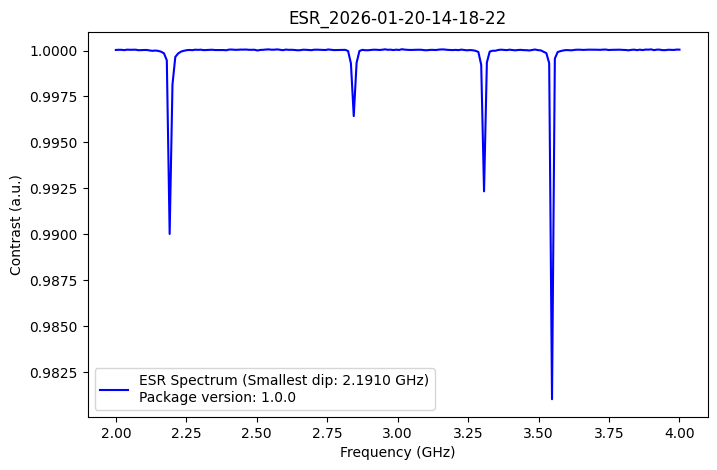

In [3]:
# Evaluate contrast and frequencies
esr_freq = esr.esr_frequencies(yaml_config)
esr_contrast = ut.contrast(data, experiment_type)

# Find dips (minima) in the contrast
dips, _ = find_peaks(-esr_contrast, prominence=0.0025)

# Calculate the 4 main dips and find the one with the smallest frequency
largest_dips_indices = np.argsort(esr_contrast[dips])[:4]
largest_dips = dips[largest_dips_indices]

smallest_freq_dip_idx = largest_dips[np.argmin(esr_freq[largest_dips])]
smallest_freq = esr_freq[smallest_freq_dip_idx]

# Plot minimalistic spectrum
plt.figure(figsize=(8, 5))

# Plot the single continuous line, appending the smallest frequency to its legend label
label_txt = (f"ESR Spectrum (Smallest dip: {smallest_freq:.4f} GHz)\n"
            f"Package version: {version}")
plt.plot(esr_freq, esr_contrast, color="blue", label=label_txt)

plt.title(yaml_config["filename"])
plt.xlabel("Frequency (GHz)")
plt.ylabel("Contrast (a.u.)")
plt.legend()
plt.show()
